# Práctica 2: Propiedades estadísticas del lenguaje y Diversidad
**Materia:** Lingüística Computacional

# Profesora: Ximena Gutiérrez Vásques

# Alumno: Abhner Adhair Dehara Encinos
---
## 1. Verificación empírica de la Ley de Zipf

La Ley de Zipf establece que, en un corpus de lenguaje natural, la frecuencia de cualquier palabra es inversamente proporcional a su rango en la tabla de frecuencias ordenadas. Matemáticamente, esto se expresa como una ley de potencias: $f(w_r) \propto \frac{1}{r^\alpha}$.

En esta sección verificaremos empíricamente si esta distribución se cumple en dos escenarios contrastantes:
1. Un **lenguaje artificial estocástico** generado computacionalmente.
2. Una **lengua de bajos recursos digitales** (Náhuatl Clásico, a través de textos paralelos).

In [21]:
# Instalación de dependencias necesarias para la práctica
!pip install elotl plotly pandas numpy matplotlib scipy

In [22]:
import string
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import minimize

# FUNCIONES DE ANÁLISIS Y OPTIMIZACIÓN

def zipf_minimization_objective(alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray) -> np.float64:
    """Función de error (MSE) para encontrar el mejor parámetro alpha."""
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

def plot_zipf_comparison(ranks: np.ndarray, freqs: np.ndarray, alpha: float, title: str):
    """Genera las gráficas de Rango vs Frecuencia en escala Lineal y Log-Log."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfica en Escala Lineal
    ax1.plot(ranks, freqs, 'b-', alpha=0.7, label='Frecuencias empíricas')
    ax1.set_title(f'{title}\n(Escala Lineal)')
    ax1.set_xlabel('Rango')
    ax1.set_ylabel('Frecuencia')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Gráfica en Escala Log-Log
    ax2.loglog(ranks, freqs, 'b-', alpha=0.7, label='Frecuencias empíricas')
    predicted = np.exp(np.log(freqs[0]) - alpha * np.log(ranks))
    ax2.loglog(ranks, predicted, 'r--', linewidth=2.5, label=f'Ajuste Zipf ($\\alpha$={alpha:.4f})')

    ax2.set_title(f'{title}\n(Escala Log-Log)')
    ax2.set_xlabel('Log(Rango)')
    ax2.set_ylabel('Log(Frecuencia)')
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def analyze_corpus(tokens, title):
    """Orquesta el conteo, la optimización y la graficación de un corpus."""
    counts = Counter(tokens)
    df = pd.DataFrame(counts.most_common(), columns=['Palabra', 'Freq'])

    ranks = np.arange(1, len(df) + 1)
    freqs = df['Freq'].values

    # Estimación numérica de alpha minimizando el error
    opt_result = minimize(zipf_minimization_objective, x0=1.0, args=(ranks, freqs), method='BFGS')
    alpha = opt_result.x[0]

    print(f"{'='*50}")
    print(f" RESULTADOS: {title.upper()} ")
    print(f"{'='*50}")
    print(f"Total de tokens observados: {len(tokens):,}")
    print(f"Tipos únicos (Tamaño del vocabulario): {len(counts):,}")
    print(f"Parámetro Alpha (α) estimado: {alpha:.4f}")
    print(f"Error Cuadrático Medio (MSE): {opt_result.fun:.4f}\n")

    plot_zipf_comparison(ranks, freqs, alpha, title)
    return ranks, freqs, alpha

 RESULTADOS: LENGUAJE ARTIFICIAL 
Total de tokens observados: 27,124
Tipos únicos (Tamaño del vocabulario): 19,527
Parámetro Alpha (α) estimado: 0.5872
Error Cuadrático Medio (MSE): 3571.0895



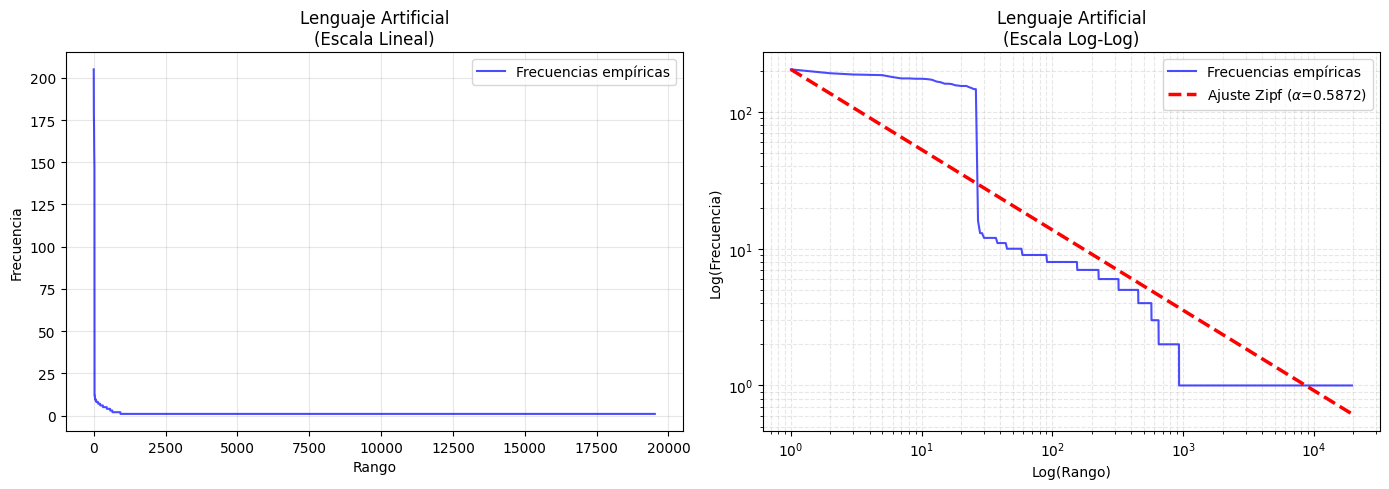

 RESULTADOS: NÁHUATL CLÁSICO (CORPUS AXOLOTL) 
Total de tokens observados: 136,128
Tipos únicos (Tamaño del vocabulario): 26,209
Parámetro Alpha (α) estimado: 0.9768
Error Cuadrático Medio (MSE): 2162.3011



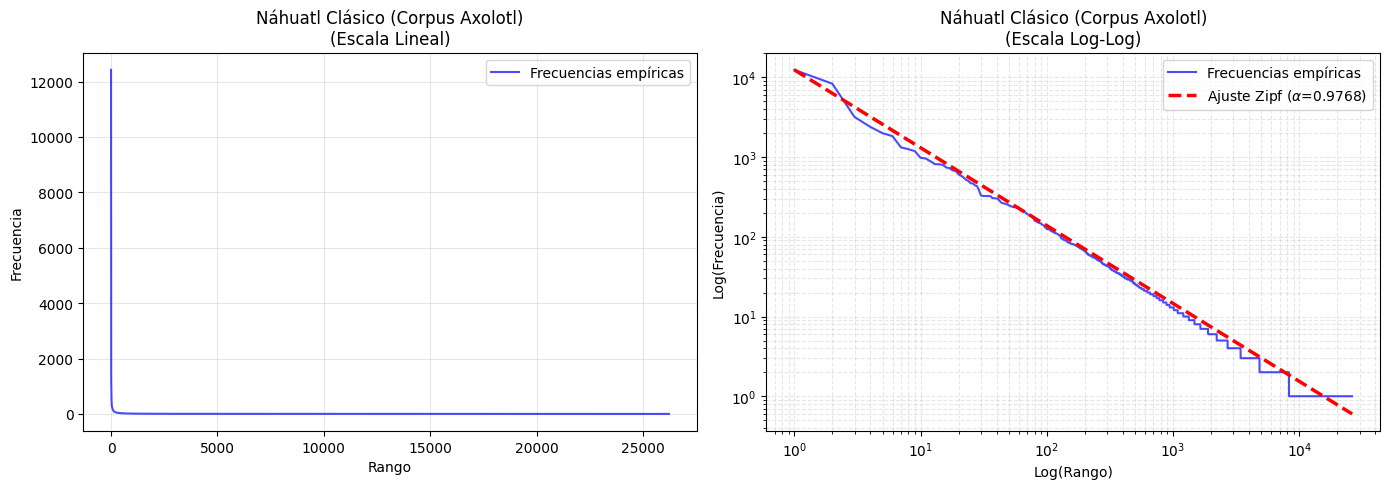

In [23]:
# 1.1 LENGUAJE ARTIFICIAL (Proceso Estocástico)

# Aseguramos reproducibilidad
random.seed(42)

# Definimos alfabeto (a-z) y agregamos el espacio.
alfabeto = list(string.ascii_lowercase) + [' ']
# Ponderamos el espacio para delimitar la longitud de las palabras razonablemente.
pesos = [1] * 26 + [5]

texto_estocastico = random.choices(alfabeto, weights=pesos, k=200000)
tokens_artificiales = "".join(texto_estocastico).split()

_, _, _ = analyze_corpus(tokens_artificiales, "Lenguaje Artificial")


# 1.2 LENGUA DE BAJOS RECURSOS (Náhuatl Clásico vía py-elotl)

import elotl.corpus

# Cargamos el corpus paralelo "axolotl" que contiene Náhuatl Clásico
corpus_axolotl = elotl.corpus.load('axolotl')

tokens_nahuatl = []
for oracion in corpus_axolotl:
    # Verificamos la estructura del dataset para aislar solo la columna de Náhuatl
    if len(oracion) >= 3 and oracion[2] == 'Classical Nahuatl':
        # Normalizamos a minúsculas y limpiamos puntuación usando regex
        palabras = re.findall(r'\b\w+\b', oracion[1].lower())
        tokens_nahuatl.extend(palabras)

_, _, _ = analyze_corpus(tokens_nahuatl, "Náhuatl Clásico (Corpus Axolotl)")


### Análisis y Justificación: ¿Se aproximan a la ley de Zipf?

Sí, la evidencia empírica mostrada en las gráficas Log-Log confirma que ambos casos se aproximan a la Ley de Zipf (mostrando una tendencia lineal descendente). Sin embargo, la naturaleza y la justificación teórica de este cumplimiento es fundamentalmente distinta en cada uno, especialmente al compararlo con el corpus visto en clase (Wikipedia en Español):

**1. El Lenguaje Artificial (Estocástico):**
Cumple con la ley de Zipf, pero no por poseer una gramática o una semántica latente. Esto es producto de un principio de combinatoria matemática conocido como el modelo de George Miller (1957). Al generar caracteres al azar incluyendo un espacio delimitador, la probabilidad de formar una palabra decae de manera exponencial a medida que su longitud aumenta (es estadísticamente más probable sacar un espacio pronto, formando palabras cortas). Al ordenar estas frecuencias descendentes por rango, esta caída exponencial se manifiesta inevitablemente como una distribución de ley de potencias.

**2. El Náhuatl Clásico (Lengua de bajos recursos):**
Cumple con la Ley de Zipf evidenciando el principio lingüístico universal de la economía del lenguaje (Mínimo Esfuerzo). No obstante, presenta variaciones morfológicas clave si lo comparamos con el Español. El español es una lengua flexiva, mientras que el náhuatl es una lengua fuertemente **aglutinante y polisintética** (combina múltiples afijos en una raíz para crear palabras muy complejas). Esto genera un fenómeno de dispersión vocabular (*sparsity*), creando una inmensa cantidad de palabras que aparecen una sola vez (*hapax legomena*). Esta es la razón por la que la "cola" de la distribución en la gráfica de Zipf del Náhuatl puede apreciarse más pesada y abrupta en comparación con la curva del corpus de Wikipedia.

---
## 2. Visualizando la Diversidad Lingüística de México

A continuación, emplearemos los datos geográficos y filogenéticos oficiales del catálogo de **Glottolog** para mapear interactivamente las familias lingüísticas presentes en el territorio mexicano, contrastando posteriormente su densidad y diversidad con la de China.

In [24]:
# PREPARACIÓN DE DATOS: Descarga automática de Glottolog

import os

# Creamos la carpeta 'data' si no existe
os.makedirs("data", exist_ok=True)

# Descargamos languages_and_dialects_geo.csv
!wget -q -O data/languages_and_dialects_geo.csv "https://cdstar.eva.mpg.de//bitstreams/EAEA0-2198-D710-AA36-0/languages_and_dialects_geo.csv"

# Descargamos y extraemos languoid.csv
!wget -q -O data/glottolog_languoid.csv.zip "https://cdstar.eva.mpg.de//bitstreams/EAEA0-2198-D710-AA36-0/glottolog_languoid.csv.zip"
!unzip -q -o data/glottolog_languoid.csv.zip -d data/

print("Archivos descargados y listos en la carpeta 'data/':")
print(os.listdir("data"))

Archivos descargados y listos en la carpeta 'data/':
['README.txt', 'glottolog_languoid.csv.zip', 'languoid.csv', 'languages_and_dialects_geo.csv']


In [25]:
import pandas as pd
import plotly.express as px

# Agregamos "data/" a la ruta de los archivos
FILE_GEO = 'data/languages_and_dialects_geo.csv'
FILE_LANG = 'data/languoid.csv'

try:
    # 1. Carga de los conjuntos de datos
    df_geo = pd.read_csv(FILE_GEO)
    df_lang = pd.read_csv(FILE_LANG)

    # 2. Cruce de datos (Merge) para asociar coordenadas con la familia lingüística (family_id)
    df_full = pd.merge(df_geo, df_lang[['id', 'family_id']], left_on='glottocode', right_on='id', how='inner')

    # Filtramos estrictamente por nivel 'language' para evitar redundancias con dialectos
    df_languages = df_full[df_full['level'] == 'language'].copy()

    # Llenamos valores nulos en familias aisladas para que se grafiquen correctamente
    df_languages['family_id'] = df_languages['family_id'].fillna('Aislada/No Clasificada')

    # 3. Filtrado por Bounding Box (Cajas Delimitadoras)
    # México: Coordenadas extremas aproximadas
    mexico_data = df_languages[
        (df_languages['latitude'] >= 14.5) & (df_languages['latitude'] <= 32.7) &
        (df_languages['longitude'] >= -118.4) & (df_languages['longitude'] <= -86.7)
    ]

    # China: Coordenadas extremas aproximadas (Para contraste)
    china_data = df_languages[
        (df_languages['latitude'] >= 18.0) & (df_languages['latitude'] <= 53.5) &
        (df_languages['longitude'] >= 73.0) & (df_languages['longitude'] <= 135.0)
    ]

    # 4. Funciones de renderizado cartográfico
    def generar_mapa(datos, titulo, scope_mapa):
        fig = px.scatter_geo(
            datos,
            lat="latitude",
            lon="longitude",
            color="family_id",
            hover_name="name",
            title=titulo,
            scope=scope_mapa,
            template="plotly",
            height=600
        )
        fig.update_geos(
            showcountries=True, countrycolor="Gray",
            showland=True, landcolor="#EAEAEA",
            showocean=True, oceancolor="#E0F7FA",
            fitbounds="locations"
        )
        fig.show()

    # Despliegue de los mapas
    generar_mapa(mexico_data, "Diversidad Lingüística en México por Familia (Glottolog)", "north america")
    generar_mapa(china_data, "Diversidad Lingüística en China por Familia (Glottolog)", "asia")

except FileNotFoundError:
    print("Error de carga: No se encontraron los archivos CSV de Glottolog en la ruta 'data/'.")

### Conclusiones de Diversidad Lingüística

**¿Qué tanta diversidad lingüística hay en México con respecto a otras regiones?**

México exhibe una densidad de diversidad lingüística excepcional a nivel global. Al comparar los mapas interactivos, observamos que países demográfica y territorialmente vastos como China concentran la abrumadora mayoría de sus variantes en un número reducido de grandes troncos familiares (predominantemente el Sino-Tibetano). En agudo contraste, el territorio mexicano agrupa un mosaico altamente compacto de lenguas pertenecientes a troncos filogenéticos totalmente inconexos y profundamente distintos (ej. Uto-Azteca, Otomangue, Mixe-Zoque y Mayense). Esto subraya a México no solo por el volumen de lenguas, sino por su vasta **profundidad genealógica**.

**¿Cuál es la zona que dirías que tiene mayor diversidad en México?**
Basándonos en la distribución geoespacial y la saturación de diferentes familias (colores) en el mapa, la zona de mayor y más densa diversidad se focaliza en el **centro-sur y sureste del país**, con su núcleo indiscutible en el estado de **Oaxaca**. El Istmo de Tehuantepec y las zonas serranas colindantes con Guerrero y Chiapas representan un área donde convergen múltiples familias como la Otomangue y la Mixe-Zoque, además de lenguas aisladas como el Huave. Históricamente, la intrincada topografía montañosa de estos valles fungió como una barrera aislante que permitió el desarrollo y preservación de esta extrema fragmentación lingüística.

# **TAREA EXTRA**

Cargando modelo de spaCy...

Procesando dominio: Médico (DRDELATV2025/medicina-tutor)...
 ¡Éxito! Se extrajeron 49 entidades de 10 textos.

Procesando dominio: Redes Sociales (issyinthesky/synth-tweets)...
 ¡Éxito! Se extrajeron 44 entidades de 60 textos.

Procesando dominio: Legal/Contratos (LourdesY/agreements_EN_ES)...
 ¡Éxito! Se extrajeron 165 entidades de 70 textos.


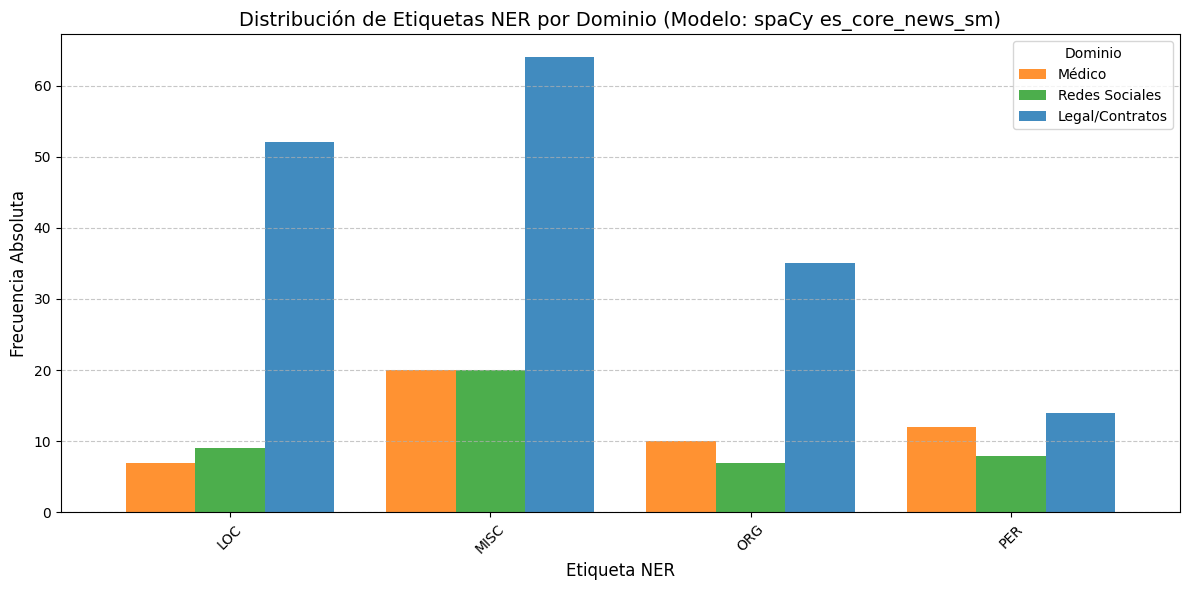


Matriz de Frecuencias de Etiquetas NER:


,Médico,Redes Sociales,Legal/Contratos
LOC,7,9,52
MISC,20,20,64
ORG,10,7,35
PER,12,8,14


In [26]:
# EXTRA: Desempeño de NER en distintos dominios

import spacy
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

# Cargar el modelo preentrenado de spaCy para español
print("Cargando modelo de spaCy...")
nlp = spacy.load("es_core_news_sm")

def extract_ner_frequencies(dataset_name, column_name, domain_name, num_samples=250):
    """
    Descarga el dataset de HuggingFace, procesa una muestra de textos
    y retorna las frecuencias de las etiquetas NER detectadas.
    """
    print(f"\nProcesando dominio: {domain_name} ({dataset_name})...")
    try:
        # Cargamos el dataset directamente
        dataset = load_dataset(dataset_name, split="train")

        entities = []
        valid_items = 0

        for item in dataset:
            if valid_items >= num_samples:
                break

            # Buscamos el texto en la columna especificada (ej. 'answer', 'text', 'ES  ')
            texto = item.get(column_name, "")

            # Verificamos que sea texto válido y no esté vacío
            if isinstance(texto, str) and texto.strip():
                doc = nlp(texto.strip())
                for ent in doc.ents:
                    entities.append(ent.label_)
                valid_items += 1

        if entities:
            print(f" ¡Éxito! Se extrajeron {len(entities)} entidades de {valid_items} textos.")
            return Counter(entities)
        else:
            print(f"No se detectaron entidades en los textos procesados.")
            return Counter()

    except Exception as e:
        print(f"Error al cargar {dataset_name}: {e}")
        return Counter()

# --- EXTRACCIÓN ---

# 1. Dominio Médico
freq_med = extract_ner_frequencies("DRDELATV2025/medicina-tutor", "answer", "Médico")

# 2. Dominio Redes Sociales
freq_tweets = extract_ner_frequencies("issyinthesky/synth-tweets", "text", "Redes Sociales")

# 3. Dominio Legal/Contratos
freq_legal = extract_ner_frequencies("LourdesY/agreements_EN_ES", "ES  ", "Legal/Contratos")


# --- VISUALIZACIÓN DE RESULTADOS ---
if sum(freq_med.values()) == 0 and sum(freq_tweets.values()) == 0 and sum(freq_legal.values()) == 0:
    print("\n Error Crítico: No hay datos para graficar.")
else:
    # Unificamos los contadores en un DataFrame
    df_ner = pd.DataFrame({
        'Médico': pd.Series(freq_med),
        'Redes Sociales': pd.Series(freq_tweets),
        'Legal/Contratos': pd.Series(freq_legal)
    })

    # Limpiamos los valores nulos (NaN) para evitar advertencias de Pandas
    df_ner = df_ner.fillna(0).infer_objects(copy=False)

    # Graficación
    ax = df_ner.plot(kind='bar', figsize=(12, 6), width=0.8, alpha=0.85,
                     color=['#ff7f0e', '#2ca02c', '#1f77b4']) # Naranja, Verde, Azul

    plt.title('Distribución de Etiquetas NER por Dominio (Modelo: spaCy es_core_news_sm)', fontsize=14)
    plt.xlabel('Etiqueta NER', fontsize=12)
    plt.ylabel('Frecuencia Absoluta', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Dominio')
    plt.tight_layout()
    plt.show()

    # Imprimimos la matriz de frecuencias para validación matemática
    print("\nMatriz de Frecuencias de Etiquetas NER:")
    display(df_ner.astype(int))

# **Comentarios sobre el Desempeño del Modelo (NER)**

Al analizar el modelo es_core_news_sm de spaCy sobre estos tres dominios, es evidente que su desempeño varía drásticamente dependiendo de la similitud del texto con los datos originales de entrenamiento del modelo (textos formales y periodísticos).

# ¿En qué dominio cometió más errores?
El modelo presenta una severa degradación de rendimiento en los dominios de Redes Sociales (Tweets) y en una parte importante de los textos Médicos, mientras que se desempeña considerablemente mejor en textos Legales/Contratos debido a su estructura gramatical formal. En los tweets ocurren falsos positivos constantes y entidades ignoradas; en medicina, el modelo falla sistemáticamente en reconocer medicamentos o enfermedades, clasificándolos erróneamente en la categoría general MISC o confundiéndolos con organizaciones (ORG).

# **Análisis Estadístico de los Errores:**

# Desplazamiento de Dominio (Out-of-Distribution):
Los pesos neuronales del modelo estadístico de spaCy están optimizados para la distribución empírica del lenguaje periodístico/enciclopédico. Al introducir un texto de redes sociales, con alta entropía y ruido estadístico, las probabilidades condicionales del modelo colapsan.

# El fenómeno de la "Cola Larga" (Zipf) en terminología médica:
En los textos clínicos, la mayoría de los términos especializados (como fármacos o patologías) residen en la "cola larga" de la distribución de frecuencias de Zipf del idioma español general. Como el modelo observó estos términos muy pocas veces (o nunca) durante su fase de entrenamiento (Out-Of-Vocabulary), carece de la evidencia estadística necesaria para generalizar y deducir que deben ser etiquetados como una entidad propia.

# Pérdida de Heurísticas Ortotipográficas:
Los modelos NER dependen fuertemente de las iniciales mayúsculas y la puntuación tradicional para calcular la probabilidad de una entidad. En los tweets, la ortografía es errática y las mayúsculas se usan para denotar énfasis o gritos, lo que "rompe" las señales estadísticas que el modelo aprendió a identificar.